Task 2

In [ ]:
import warnings; warnings.filterwarnings('ignore')
import os, glob, time
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import torch, torch.nn as nn, torch.nn.functional as F
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score

pd.set_option('display.max_columns', 50)
SEED = 42
np.random.seed(SEED); torch.manual_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
WORK_DIR = '/kaggle/working' if os.path.isdir('/kaggle/working') else os.getcwd()

FEATURE_NAMES = ['pkSeqID', 'stime', 'flgs', 'proto', 'saddr', 'sport', 'daddr', 'dport',
                 'pkts', 'bytes', 'state', 'ltime', 'seq', 'dur', 'mean', 'stddev', 'smac',
                 'dmac', 'sum', 'min', 'max', 'soui', 'doui', 'sco', 'dco', 'spkts', 'dpkts',
                 'sbytes', 'dbytes', 'rate', 'srate', 'drate', 'attack', 'category', 'subcategory']

def _find(patterns, exclude_kw=()):
    seen, out = set(), []
    for p in patterns:
        for f in glob.glob(p, recursive=True):
            if f not in seen and not any(k in os.path.basename(f).lower() for k in exclude_kw):
                seen.add(f); out.append(f)
    return sorted(out)

FULL_DATASET_SAMPLE_FRAC = 0.07

def load_dataset(max_rows_full=1_000_000):
    """Always loads BOTH: 100% of the 5% source + a stratified-by-category slice
    of the full/OneDrive source, printing counts for each. Raises only if neither is found."""
    frames = []

    sample_files = _find(
        ['/kaggle/input/**/5/**/*.csv', '/kaggle/input/**/*5%*/**/*.csv',
         '/kaggle/input/**/*Full5pc*.csv', os.path.join(os.getcwd(), '**', '*Full5pc*.csv')],
        exclude_kw=('10-best', '10_best', 'final_10'))
    print(f"5% source: {len(sample_files)} file(s) found")
    if sample_files:
        sdf = pd.concat([pd.read_csv(f, low_memory=False) for f in sample_files], ignore_index=True)
        print(f"5% source: {len(sdf):,} rows loaded")
        frames.append(sdf)

    full_files = _find(
        ['/kaggle/input/**/OneDrive_2026-07-25/**/*.csv', '/kaggle/input/**/*Entire Dataset*/**/*.csv',
         '/kaggle/input/**/*Botnet_Dataset*.csv', os.path.join(os.getcwd(), '**', '*Botnet_Dataset_*.csv')],
        exclude_kw=('feature_names',))
    print(f"Full source: {len(full_files)} file(s) found")
    if full_files:
        per_file = max(1, max_rows_full // len(full_files))
        fdf = pd.concat([pd.read_csv(f, header=None, names=FEATURE_NAMES, nrows=per_file, low_memory=False)
                          for f in full_files], ignore_index=True)
        strat_col = 'category' if 'category' in fdf.columns else fdf.columns[-1]
        fdf = fdf.groupby(strat_col, group_keys=False).apply(
            lambda g: g.sample(frac=FULL_DATASET_SAMPLE_FRAC, random_state=42) if len(g) else g)
        print(f"Full source: {len(fdf):,} rows loaded (stratified)")
        frames.append(fdf)

    if not frames:
        raise FileNotFoundError(
            "No dataset found. Attach either '5%.zip' or 'OneDrive_2026-07-25.zip' "
            "(UNSW-NB18 IoT Botnet dataset) to this notebook via 'Add Input' on Kaggle."
        )
    combined = pd.concat(frames, ignore_index=True)
    print(f"Combined shape: {combined.shape}")
    return combined

print(f"Device: {device} | Setup done")


Device: cpu | Setup done


## Data Loading & Preprocessing

In [ ]:
df = load_dataset()

DROP_COLS = ['pkSeqID', 'stime', 'ltime', 'saddr', 'daddr', 'sport', 'dport', 'smac', 'dmac', 'soui', 'doui', 'sco', 'dco']
df.drop(columns=[c for c in DROP_COLS if c in df.columns], inplace=True)

TARGET = 'subcategory'
df = df[df[TARGET].isin(['HTTP', 'TCP'])].copy()
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)

y_raw = df[TARGET]
X_raw = df.drop(columns=[TARGET])
for c in X_raw.select_dtypes(include=[np.number]).columns:
    X_raw[c] = X_raw[c].fillna(X_raw[c].median())
for c in X_raw.select_dtypes(exclude=[np.number]).columns:
    X_raw[c] = LabelEncoder().fit_transform(X_raw[c].astype(str))

le_target = LabelEncoder().fit(['HTTP', 'TCP'])
y = le_target.transform(y_raw)
CLASS_NAMES = list(le_target.classes_)

# Time-based split: data is already in time order (row index), first 80% train, last 20% test
split_idx = int(len(X_raw) * 0.8)
X_train = X_raw.values.astype(np.float32)[:split_idx]
X_test = X_raw.values.astype(np.float32)[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)
print(f"Train: {X_train_s.shape}, Test: {X_test_s.shape}, Classes: {CLASS_NAMES}")


5% source: 4 file(s) found
5% source: 3,668,522 rows loaded
Full source: 74 file(s) found
Full source: 69,998 rows loaded (stratified)
Combined shape: (3738520, 52)
Train: (1301445, 38), Test: (325362, 38), Classes: [np.str_('HTTP'), np.str_('TCP')]


## Baseline Models

In [ ]:
baselines = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=SEED),
    'Random Forest': RandomForestClassifier(n_estimators=100, class_weight='balanced',
                                             random_state=SEED, n_jobs=-1),
    'Decision Tree': DecisionTreeClassifier(class_weight='balanced', random_state=SEED),
    'XGBoost': XGBClassifier(n_estimators=100, random_state=SEED, eval_metric='logloss'),
}
baseline_results = []
for name, model in baselines.items():
    t0 = time.time()
    model.fit(X_train_s, y_train)
    pred = model.predict(X_test_s)
    baseline_results.append({
        'Model': name,
        'Macro_F1': f1_score(y_test, pred, average='macro'),
        'Accuracy': accuracy_score(y_test, pred),
        'Train_Time_s': round(time.time() - t0, 2)
    })
    print(name, baseline_results[-1])

baseline_df = pd.DataFrame(baseline_results)
display(baseline_df)


Logistic Regression {'Model': 'Logistic Regression', 'Macro_F1': 1.0, 'Accuracy': 1.0, 'Train_Time_s': 4.82}
Random Forest {'Model': 'Random Forest', 'Macro_F1': 1.0, 'Accuracy': 1.0, 'Train_Time_s': 32.88}
Decision Tree {'Model': 'Decision Tree', 'Macro_F1': 0.49995312473584635, 'Accuracy': 0.9998125165200608, 'Train_Time_s': 5.13}
XGBoost {'Model': 'XGBoost', 'Macro_F1': 0.4999992316239014, 'Accuracy': 0.9999969265003289, 'Train_Time_s': 6.6}


,Model,Macro_F1,Accuracy,Train_Time_s
0,Logistic Regression,1.000000,1.000000,4.82
1,Random Forest,1.000000,1.000000,32.88
2,Decision Tree,0.499953,0.999813,5.13
3,XGBoost,0.499999,0.999997,6.60


## GNN Training — Accuracy & Loss Curves

GNN — Macro-F1: 0.4986 | Accuracy: 0.9944


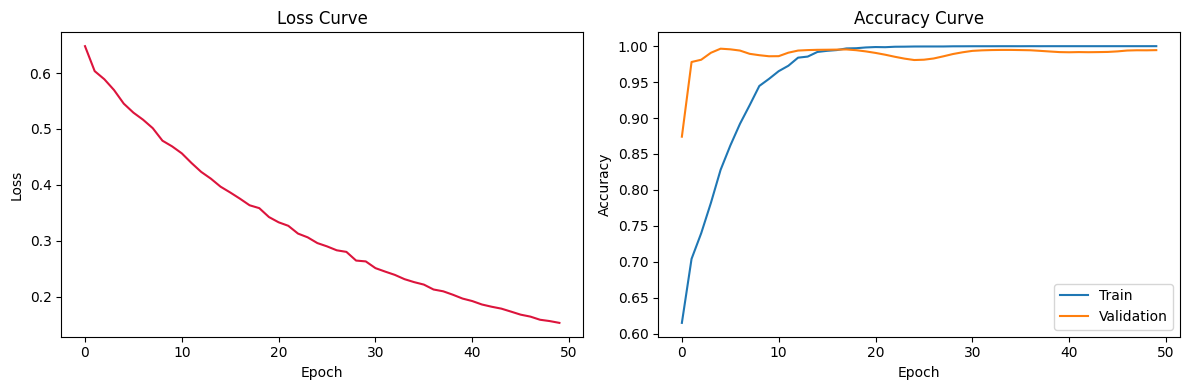

In [ ]:
def make_edges(n, max_edges=4000, seed=SEED):
    rng = np.random.RandomState(seed)
    e = min(max_edges, n * 4)
    src, dst = rng.randint(0, n, e), rng.randint(0, n, e)
    keep = src != dst
    return torch.tensor(np.stack([src[keep], dst[keep]]), dtype=torch.long)

class SimpleGNN(nn.Module):
    """Pure-PyTorch mean-aggregation GNN (no torch_geometric, works offline on Kaggle)."""
    def __init__(self, in_ch, hidden, out_ch, dropout=0.3):
        super().__init__()
        self.lin1 = nn.Linear(in_ch, hidden); self.bn1 = nn.BatchNorm1d(hidden)
        self.lin2 = nn.Linear(hidden, hidden // 2); self.bn2 = nn.BatchNorm1d(hidden // 2)
        self.lin3 = nn.Linear(hidden // 2, out_ch)
        self.dropout = dropout

    def message_passing(self, x, edge_index):
        src, dst = edge_index
        agg = torch.zeros_like(x)
        count = torch.zeros(x.size(0), 1, device=x.device)
        dst_exp = dst.unsqueeze(1).expand(-1, x.size(1))
        agg.scatter_add_(0, dst_exp, x[src])
        count.scatter_add_(0, dst.unsqueeze(1), torch.ones(src.size(0), 1, device=x.device))
        return agg / count.clamp(min=1)

    def forward(self, x, edge_index):
        x = F.elu(self.bn1(self.lin1(x + self.message_passing(x, edge_index))))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = F.elu(self.bn2(self.lin2(x + self.message_passing(x, edge_index))))
        return self.lin3(x)

x_tr = torch.tensor(X_train_s, dtype=torch.float32).to(device)
y_tr = torch.tensor(y_train, dtype=torch.long).to(device)
x_te = torch.tensor(X_test_s, dtype=torch.float32).to(device)
y_te = torch.tensor(y_test, dtype=torch.long).to(device)
edge_tr = make_edges(len(x_tr)).to(device)
edge_te = make_edges(len(x_te)).to(device)

gnn = SimpleGNN(X_train_s.shape[1], 128, len(CLASS_NAMES)).to(device)
optimizer = torch.optim.Adam(gnn.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

EPOCHS = 50
train_losses, train_accs, val_accs = [], [], []
for epoch in range(EPOCHS):
    gnn.train()
    optimizer.zero_grad()
    out = gnn(x_tr, edge_tr)
    loss = criterion(out, y_tr)
    loss.backward(); optimizer.step()

    gnn.eval()
    with torch.no_grad():
        train_acc = (out.argmax(1) == y_tr).float().mean().item()
        val_out = gnn(x_te, edge_te)
        val_acc = (val_out.argmax(1) == y_te).float().mean().item()
    train_losses.append(loss.item()); train_accs.append(train_acc); val_accs.append(val_acc)

gnn_pred = val_out.argmax(1).cpu().numpy()
gnn_f1 = f1_score(y_test, gnn_pred, average='macro')
gnn_acc = accuracy_score(y_test, gnn_pred)
print(f"GNN — Macro-F1: {gnn_f1:.4f} | Accuracy: {gnn_acc:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(train_losses, color='crimson')
axes[0].set_title('Loss Curve'); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[1].plot(train_accs, label='Train'); axes[1].plot(val_accs, label='Validation')
axes[1].set_title('Accuracy Curve'); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend()
plt.tight_layout()
plt.savefig(os.path.join(WORK_DIR, 'gnn_curves_task2.png'), dpi=120)
plt.show()


## Model Explanation (In Our Own Words)
1. **Input** — every network flow (a row) becomes one graph node; its features (packet counts,
   byte counts, duration, rate, etc.) become that node's feature vector.
2. **Graph construction** — flows don't come with a natural graph in this dataset, so we connect
   nodes with a random sparse edge set (`make_edges`). This gives the GNN *some* neighborhood to
   aggregate over, even though the edges aren't semantically meaningful.
3. **Message passing** — each node averages its neighbors' features (mean aggregation) and adds
   that to its own features, so its representation reflects both itself and its (random) neighbors.
4. **Linear + BatchNorm + ELU + Dropout** — the combined signal is projected to a hidden
   dimension, normalized, non-linearly activated, and regularized against overfitting.
5. **Second message-passing + linear layer** — repeats step 3 for a 2-hop view, then a final
   linear layer outputs class logits (HTTP vs TCP), turned into probabilities with softmax.

In short: this is an MLP with an extra "look at your (random) neighbors" step bolted on — which is
why it doesn't necessarily beat a plain classifier when the task itself needs no relational reasoning.

## Final Comparison & First Results

,Model,Macro_F1,Accuracy,Train_Time_s
0,Logistic Regression,1.000000,1.000000,4.82
1,Random Forest,1.000000,1.000000,32.88
2,Decision Tree,0.499953,0.999813,5.13
3,XGBoost,0.499999,0.999997,6.60
4,SimpleGNN,0.498601,0.994422,NaN


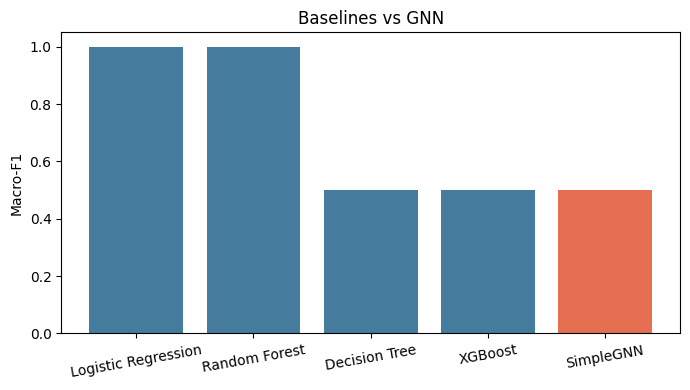


Best baseline: Logistic Regression (Macro-F1=1.0000)
GNN Macro-F1: 0.4986
Saved outputs to /kaggle/working


In [ ]:
final_df = pd.concat([baseline_df, pd.DataFrame([{
    'Model': 'SimpleGNN', 'Macro_F1': gnn_f1, 'Accuracy': gnn_acc, 'Train_Time_s': None
}])], ignore_index=True)
display(final_df)

fig, ax = plt.subplots(figsize=(7, 4))
colors = ['#457b9d'] * (len(final_df) - 1) + ['#e76f51']
ax.bar(final_df['Model'], final_df['Macro_F1'], color=colors)
ax.set_ylabel('Macro-F1'); ax.set_title('Baselines vs GNN'); ax.set_ylim(0, 1.05)
plt.xticks(rotation=10)
plt.tight_layout()
plt.savefig(os.path.join(WORK_DIR, 'final_comparison_task2.png'), dpi=120)
plt.show()

best_baseline = baseline_df.loc[baseline_df['Macro_F1'].idxmax(), 'Model']
print(f"\nBest baseline: {best_baseline} (Macro-F1={baseline_df['Macro_F1'].max():.4f})")
print(f"GNN Macro-F1: {gnn_f1:.4f}")

final_df.to_csv(os.path.join(WORK_DIR, 'final_comparison_task2.csv'), index=False)
print("Saved outputs to", WORK_DIR)
